# Analise Exploratoria - Ibovespa historico (fechamento -> retorno)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display


plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['figure.dpi'] = 110

## 1. Carregamento dos dados
Incluindo Forward Fill

Qtd de NaN antes:  7152


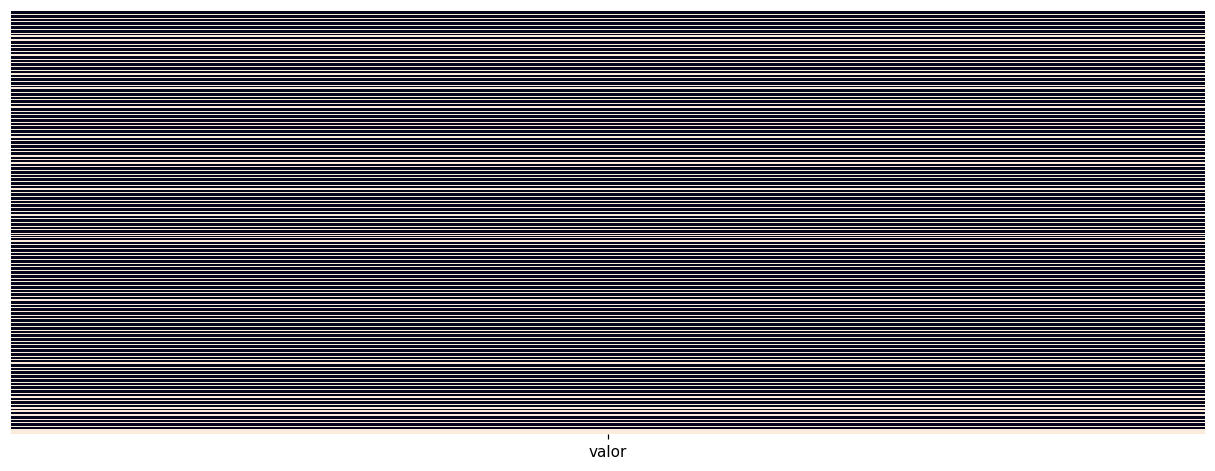

Qtd de NaN depois:  0
1968-01-02 -> 2026-05-22


,data,valor
1,1968-01-02,1.000000e-10
2,1968-01-03,1.000000e-10
3,1968-01-04,9.900000e-11
4,1968-01-05,9.700000e-11
7,1968-01-08,9.700000e-11


,data,valor
1,1968-01-02,1.000000e-10
2,1968-01-03,1.000000e-10
3,1968-01-04,9.900000e-11
4,1968-01-05,9.700000e-11
7,1968-01-08,9.700000e-11


,data,valor
21322,2026-05-18,176975.82
21323,2026-05-19,174278.86
21324,2026-05-20,177355.73
21325,2026-05-21,177649.86
21326,2026-05-22,176209.61


In [ ]:
ibov = pd.read_csv('dados/Historico_IBovespa.csv', encoding='latin-1')
ibov['data'] = pd.to_datetime(ibov['data'], errors='coerce')
ibov['valor'] = pd.to_numeric(ibov['valor'], errors='coerce')
ibov = ibov.sort_values('data').reset_index(drop=True)

print('Qtd de NaN antes: ', ibov['valor'].isna().sum())
sns.heatmap(ibov[['valor']].isnull(), yticklabels=False, cbar=False)
plt.show()

ibov.dropna(inplace=True)

print('Qtd de NaN depois: ', ibov['valor'].isna().sum())


print(ibov['data'].min().date(), '->', ibov['data'].max().date())

display(ibov.head())
display(ibov.tail())

## 2. Estatisticas descritivas

In [3]:
ibov['valor'].describe()

count    1.439800e+04
mean     3.054254e+04
std      4.165102e+04
min      9.700000e-11
25%      3.000200e-08
50%      7.551675e+03
75%      5.543990e+04
max      1.986573e+05
Name: valor, dtype: float64

## 3. Serie temporal

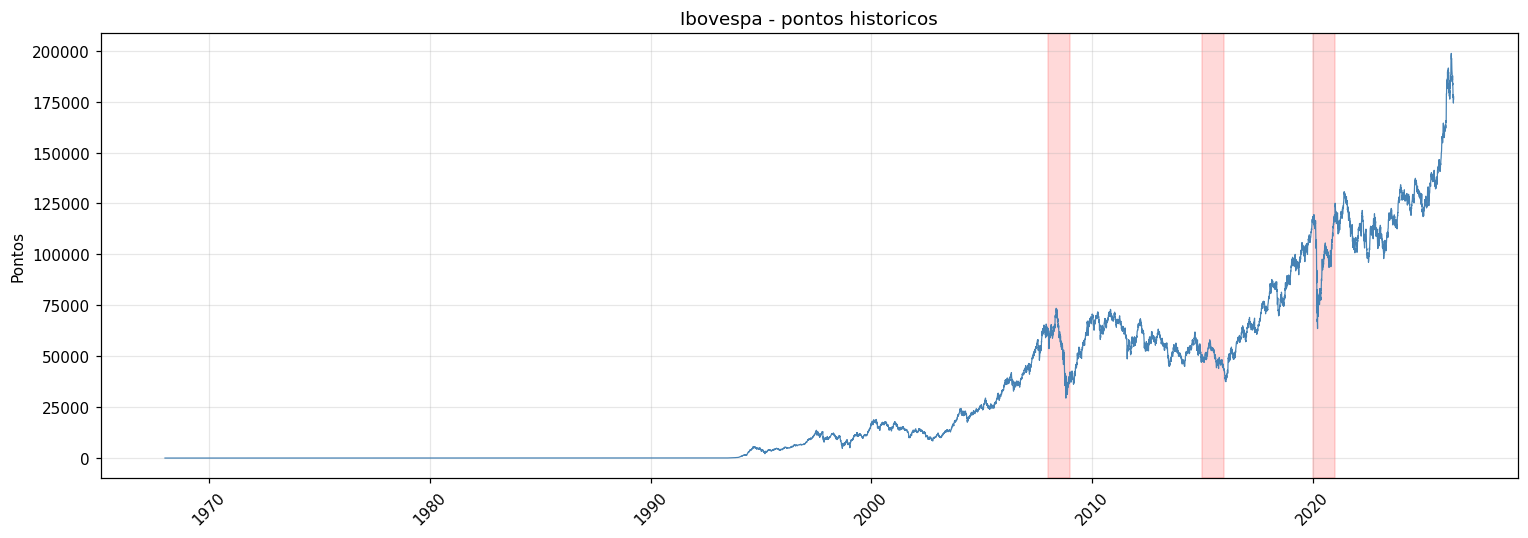

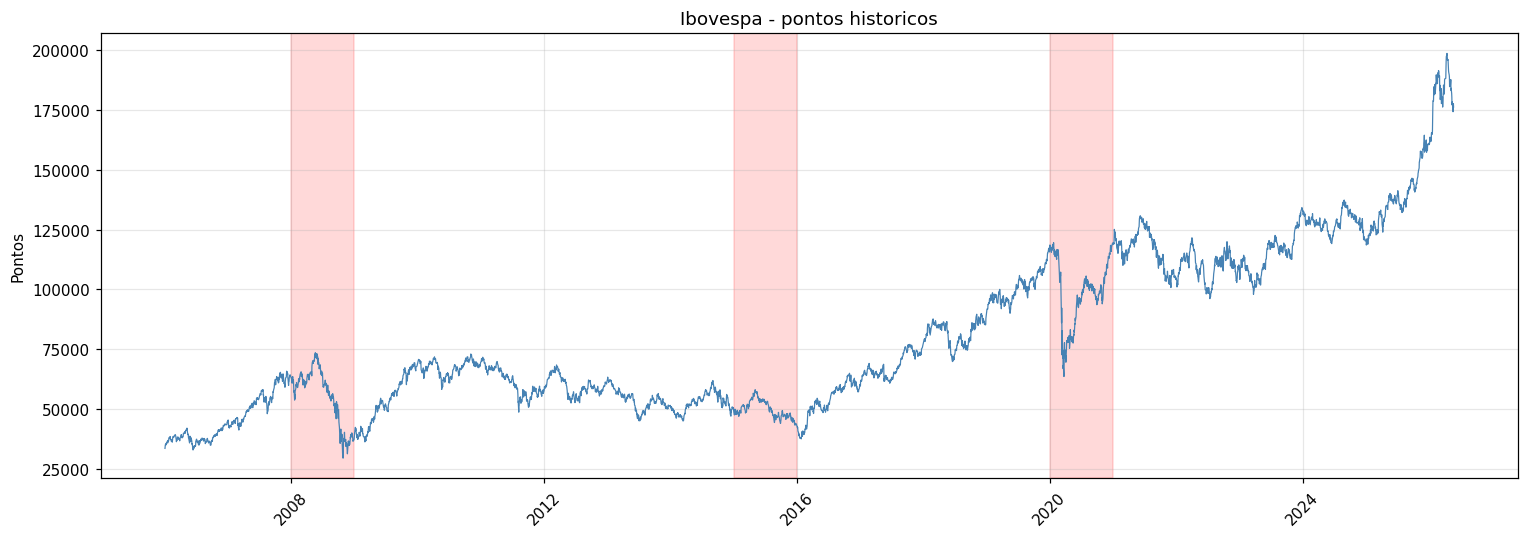

In [4]:
plt.plot(ibov['data'], ibov['valor'], linewidth=0.8, color='steelblue')
for ano in [2008, 2015, 2020]:
    plt.axvspan(pd.Timestamp(f'{ano}-01-01'), pd.Timestamp(f'{ano}-12-31'), color='red', alpha=0.15)
plt.title('Ibovespa - pontos historicos')
plt.ylabel('Pontos')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# apenas dos últimos 20 anos
ibov_20 = ibov[ibov['data'] >= '2006-01-01']
plt.plot(ibov_20['data'], ibov_20['valor'], linewidth=0.8, color='steelblue')
for ano in [2008, 2015, 2020]:
    plt.axvspan(pd.Timestamp(f'{ano}-01-01'), pd.Timestamp(f'{ano}-12-31'), color='red', alpha=0.15)
plt.title('Ibovespa - pontos historicos')
plt.ylabel('Pontos')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Retornos diarios

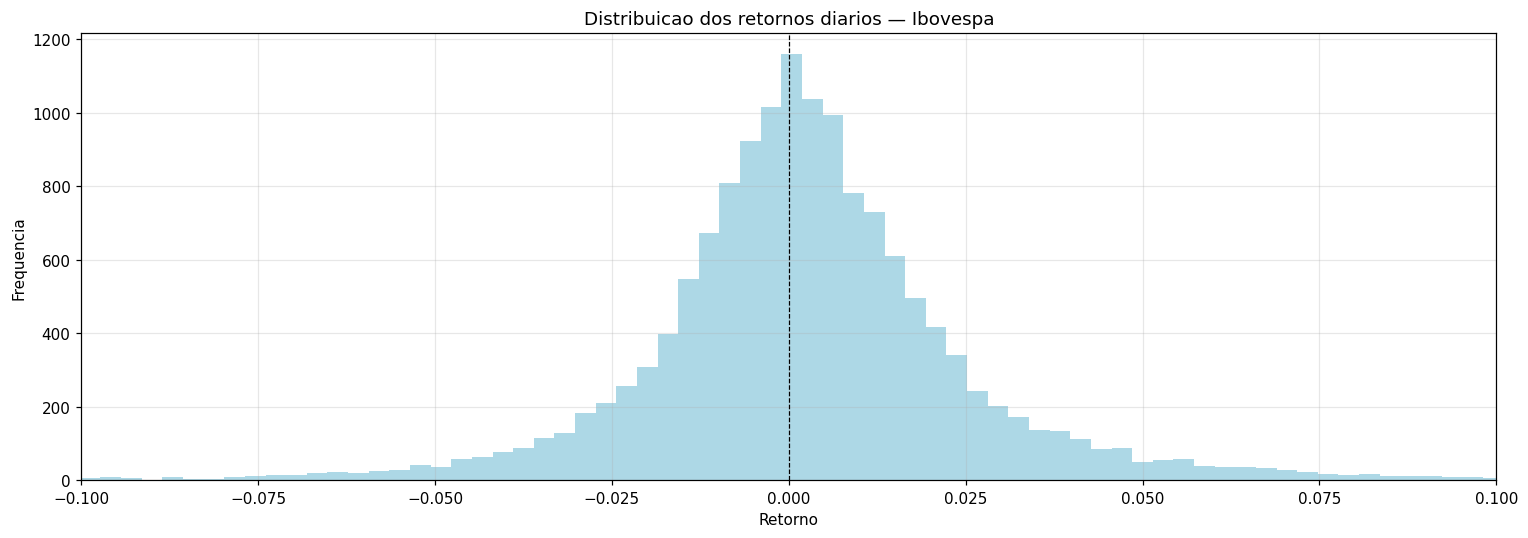

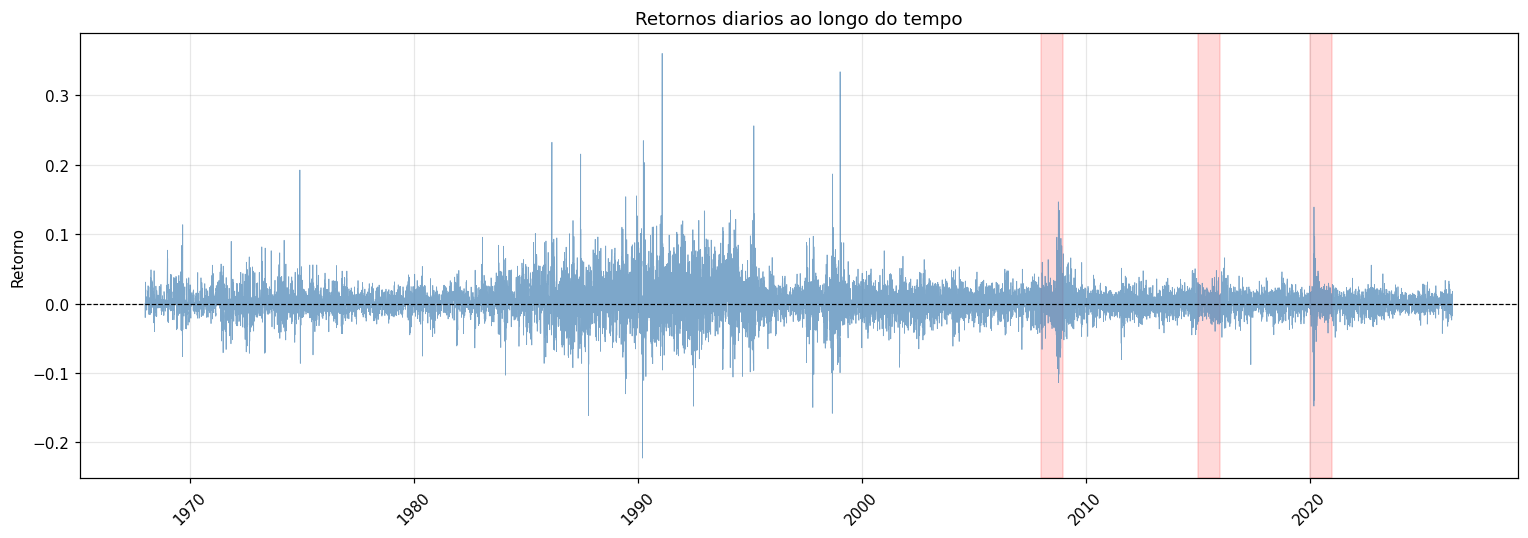

Retorno medio diario: 0.2741%
Desvio padrao diario: 2.4662%
Retorno medio diario (20 anos): 0.0464%
Desvio padrao diario (20 anos): 1.6387%


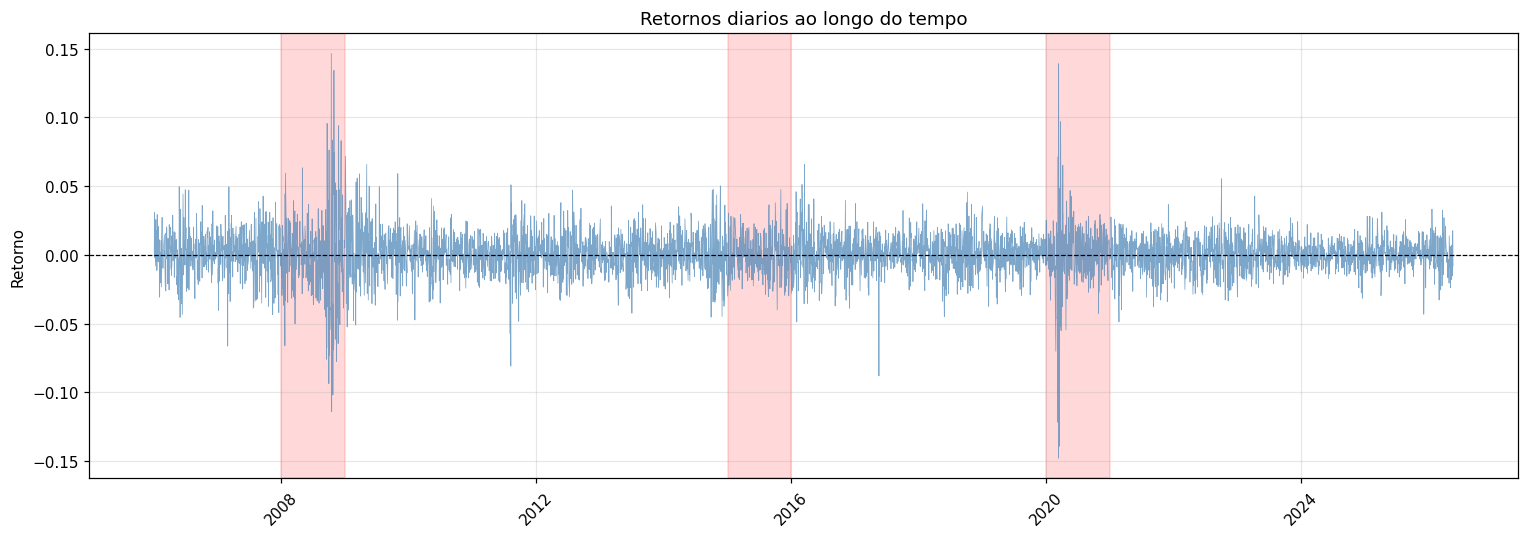

In [5]:
ibov['retorno'] = ibov['valor'].pct_change()

plt.close('all')
plt.figure(figsize=(14, 5))
plt.hist(ibov['retorno'].dropna(), bins=200, color='lightblue', edgecolor='none')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Distribuicao dos retornos diarios — Ibovespa')
plt.xlabel('Retorno')
plt.ylabel('Frequencia')
plt.grid(True, alpha=0.3)
plt.xlim(-0.1, 0.1)
plt.tight_layout()
plt.show()

plt.plot(ibov['data'], ibov['retorno'], linewidth=0.5, color='steelblue', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Retornos diarios ao longo do tempo')
plt.ylabel('Retorno')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
for ano in [2008, 2015, 2020]:
    plt.axvspan(pd.Timestamp(f'{ano}-01-01'), pd.Timestamp(f'{ano}-12-31'), color='red', alpha=0.15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


print('Retorno medio diario:', f"{ibov['retorno'].mean():.4%}")
print('Desvio padrao diario:', f"{ibov['retorno'].std():.4%}")

# apenas dos últimos 20 anos
ibov_20 = ibov[ibov['data'] >= '2006-01-01']
print('Retorno medio diario (20 anos):', f"{ibov_20['retorno'].mean():.4%}")
print('Desvio padrao diario (20 anos):', f"{ibov_20['retorno'].std():.4%}")

plt.plot(ibov_20['data'], ibov_20['retorno'], linewidth=0.5, color='steelblue', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('Retornos diarios ao longo do tempo')
plt.ylabel('Retorno')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tick_params(axis='x', rotation=45)
for ano in [2008, 2015, 2020]:
    plt.axvspan(pd.Timestamp(f'{ano}-01-01'), pd.Timestamp(f'{ano}-12-31'), color='red', alpha=0.15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Medias moveis (ultimos 10 anos)

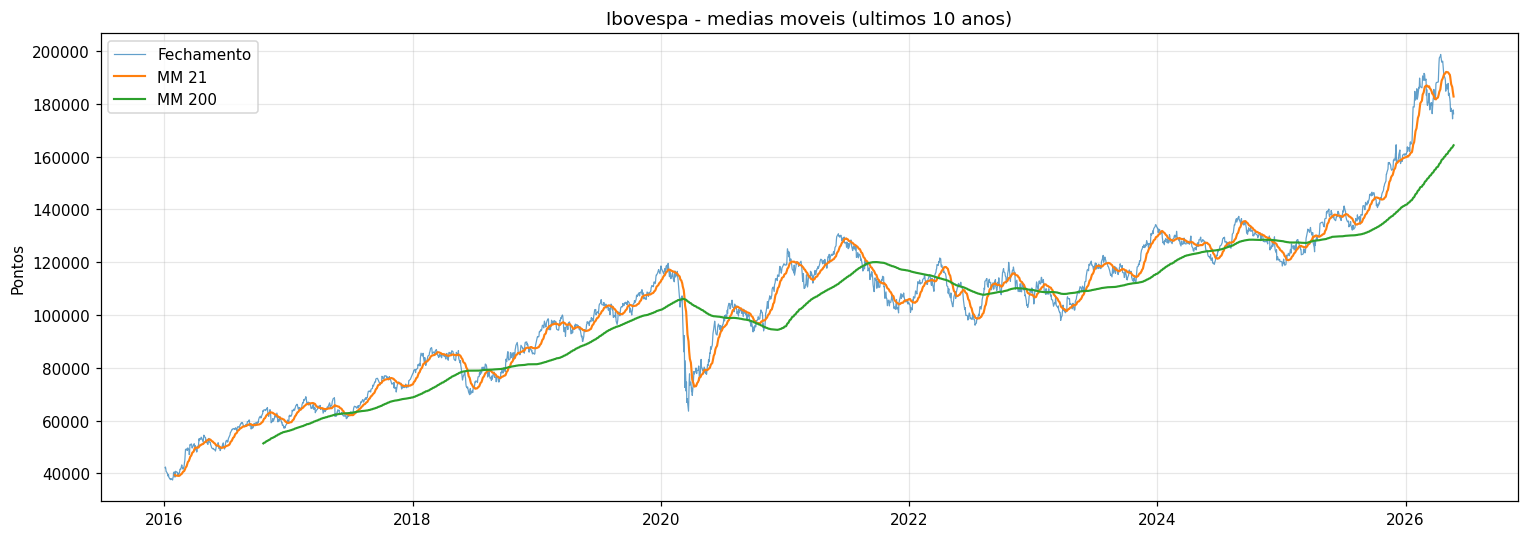

In [6]:
ano_max = ibov['data'].dt.year.max()
recente = ibov[ibov['data'].dt.year >= ano_max - 10].copy()
recente['mm21']  = recente['valor'].rolling(21).mean()
recente['mm200'] = recente['valor'].rolling(200).mean()
plt.figure(figsize=(14, 5))
plt.plot(recente['data'], recente['valor'],  label='Fechamento', linewidth=0.8, alpha=0.7)
plt.plot(recente['data'], recente['mm21'],   label='MM 21',  linewidth=1.4)
plt.plot(recente['data'], recente['mm200'],  label='MM 200', linewidth=1.4)
plt.title('Ibovespa - medias moveis (ultimos 10 anos)')
plt.ylabel('Pontos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Volatilidade realizada (janela 21 dias uteis)

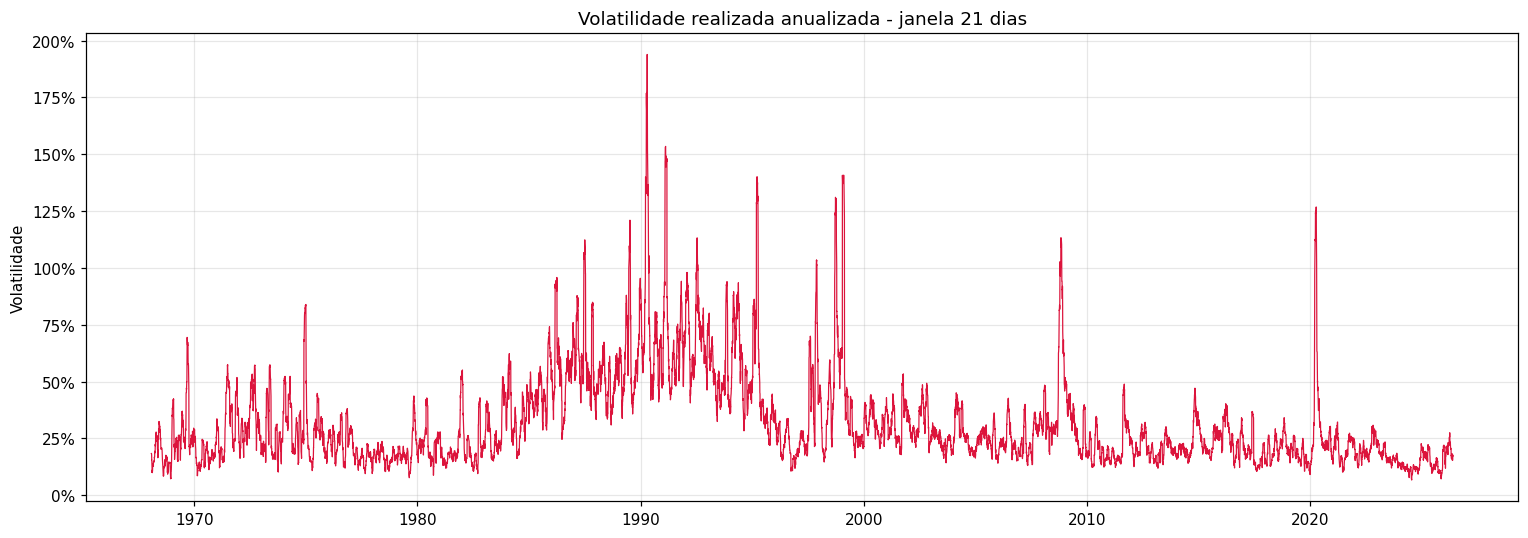

In [7]:
ibov['vol21'] = ibov['retorno'].rolling(21).std() * np.sqrt(252)

plt.plot(ibov['data'], ibov['vol21'], color='crimson', linewidth=0.8)
plt.title('Volatilidade realizada anualizada - janela 21 dias')
plt.ylabel('Volatilidade')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Salvando novo arquivo

In [8]:
arq = open('dados/Historico_retornos.csv', 'w')
arq.write('data,valor,retorno\n')

for _, row in ibov.iterrows():
    arq.write(f"{row['data'].date()},{row['valor']},{row['retorno']}\n")
    
arq.close()